In [44]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
from util.pixelmapUtil import PixelMapUtil
import numpy as np
from matplotlib import pyplot

In [46]:
color_map = "gray"
pmt = PixelMapUtil(
    gaussian_sigma=0.3
)

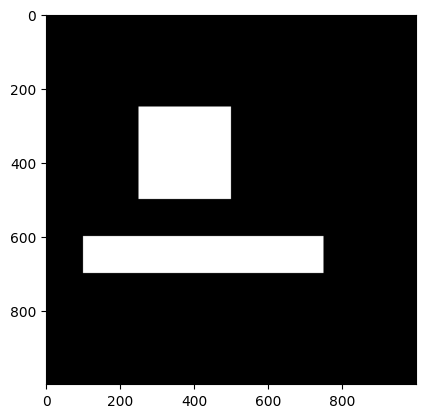

In [47]:
img = np.zeros((1000, 1000))

def draw_some_shapes(img: np.typing.NDArray):
    img[250:500, 250:500] = 1
    img[600:700, 100:750] = 1

draw_some_shapes(img)
pyplot.imshow(img, cmap=color_map)

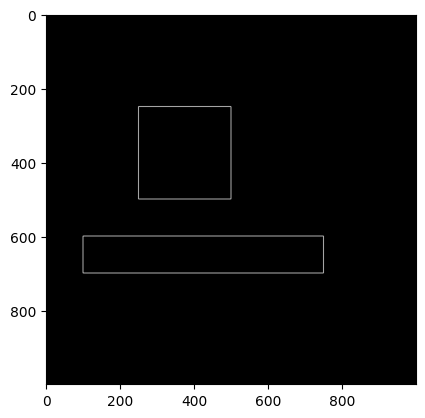

In [48]:
pyplot.imshow(pmt.get_edges(img), cmap=color_map)

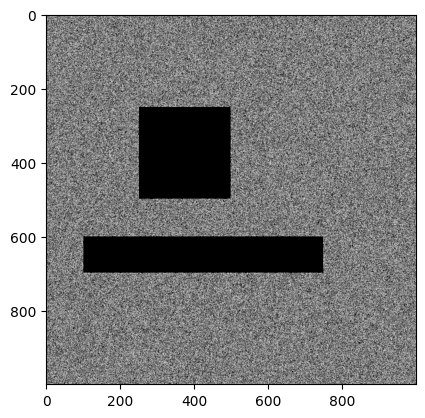

In [49]:
rng = np.random.default_rng()
noisy_img = rng.integers(low=0, high=2, size=(1000,1000))
draw_some_shapes(noisy_img)
pyplot.imshow(noisy_img, cmap=color_map)
pyplot.imshow(pmt.get_edges(noisy_img), cmap=color_map)

[[0 1 0 ... 1 1 0]
 [1 1 1 ... 1 1 0]
 [0 0 0 ... 0 1 1]
 ...
 [1 0 1 ... 1 0 1]
 [1 1 0 ... 0 0 0]
 [1 1 0 ... 1 0 0]]


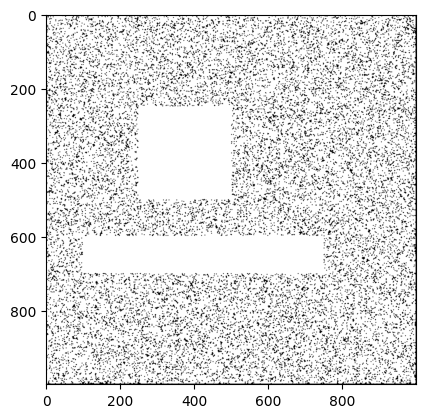

In [61]:
pmt.set_gaussian_sigma(2)
img_p = img
img_p = pmt.post_process_img(noisy_img)
pyplot.imshow(img_p, cmap=color_map)

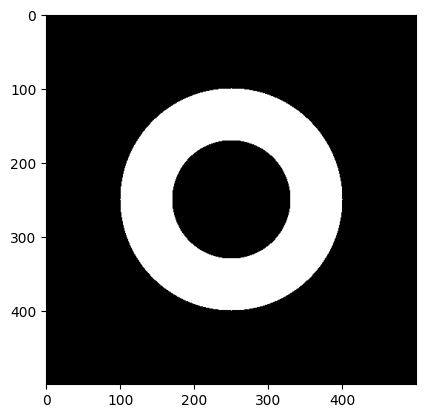

In [51]:
#This was generated quickly by gemini
def create_donut(shape=(500, 500), center=None, radius_outer=150, radius_inner=80):
    rows, cols = shape
    if center is None:
        center = (rows // 2, cols // 2)
    
    # Create coordinate grids (y, x)
    y, x = np.ogrid[:rows, :cols]
    
    # Calculate distance from center for every pixel
    dist_from_center = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    
    # Create the ring mask:
    # Inner radius <= Distance <= Outer radius
    mask = (dist_from_center <= radius_outer) & (dist_from_center >= radius_inner)
    
    return mask.astype(int) # Returns 0s and 1s

donut_mask = create_donut()
pyplot.imshow(donut_mask, cmap=color_map)

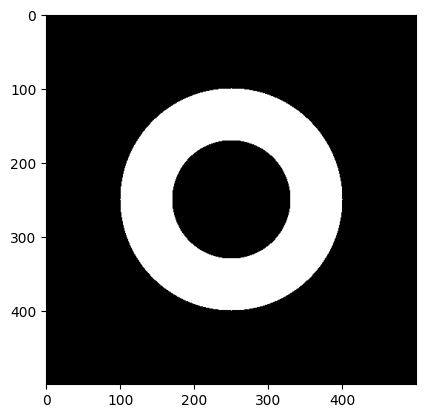

In [52]:
img_p = pmt.post_process_img(donut_mask)
pyplot.imshow(img_p, cmap=color_map)